# Automatic License Plate Recognition (ALPR)
### ECE 1513: Intro to Machine Learning — Course Project | University of Toronto, Winter 2026

---

**Pipeline Overview:**
1. Environment setup & dependency installation
2. Dataset download & preparation (Roboflow)
3. YOLO26 fine-tuning for license plate detection
4. Detection evaluation (mAP, precision, recall)
5. Image preprocessing module (CLAHE, threshold, warp)
6. OCR model setup & character recognition
7. Post-processing & regex validation
8. End-to-end pipeline integration
9. Numerical experiments & results
10. Visualization & figures

---

##Environment Setup

In [1]:
# Check GPU availability
import torch

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU found. Training will be slow on CPU.")

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
VRAM            : 15.6 GB


In [2]:
# Install all required dependencies
!pip install -q ultralytics>=8.0.0
!pip install -q easyocr>=1.7.2
!pip install -q paddleocr==2.10.0
!pip install -q paddlepaddle==3.0.0
!pip install -q roboflow
!pip install -q opencv-python-headless
!pip install -q matplotlib seaborn pandas scikit-learn

print("All dependencies installed.")

All dependencies installed.


In [3]:
RF_API_KEY = "GqKHsPyPR5NcFC3ovBoV"
OCR_ALLOWLIST = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"

In [4]:
# Core imports
import os
import re
import cv2
import json
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
from PIL import Image
from IPython.display import display, Image as IPImage

import torch
from ultralytics import YOLO
import easyocr
from paddleocr import PaddleOCR

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Global paths
ROOT        = Path("/content/alpr")       # change if running locally
DATA_DIR    = ROOT / "data"
WEIGHTS_DIR = ROOT / "weights"
RESULTS_DIR = ROOT / "results"

for d in [ROOT, DATA_DIR, WEIGHTS_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Imports OK. Project root:", ROOT)

Imports OK. Project root: /content/alpr


---
## Dataset Download & Preparation

In [8]:
# Download the Roboflow License Plate Recognition dataset (v13)
from roboflow import Roboflow

rf = Roboflow(api_key=RF_API_KEY)

project = rf.workspace("roboflow-universe-projects").project("license-plate-recognition-rxg4e")
version = project.version(12)
dataset = version.download("yolo26", location=str(DATA_DIR / "license_plates"))

DATASET_PATH = Path(dataset.location)
print("Dataset downloaded to:", DATASET_PATH)


loading Roboflow workspace...
loading Roboflow project...
Dataset downloaded to: /content/alpr/data/license_plates


In [ ]:
# Audit the dataset: count images per split and check for missing labels

splits = ["train", "valid", "test"]
stats = {}

for split in splits:
    img_dir   = DATASET_PATH / split / "images"
    label_dir = DATASET_PATH / split / "labels"

    images = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
    labels = list(label_dir.glob("*.txt")) if label_dir.exists() else []

    # Find images missing a label file
    img_stems   = {p.stem for p in images}
    label_stems = {p.stem for p in labels}
    missing     = img_stems - label_stems

    stats[split] = {
        "images" : len(images),
        "labels" : len(labels),
        "missing": len(missing)
    }
    print(f"{split:6s} | images: {len(images):5d} | labels: {len(labels):5d} | missing: {len(missing)}")

total = sum(s["images"] for s in stats.values())
print(f"\nTotal images: {total}")

train  | images:  7057 | labels:  7057 | missing: 0
valid  | images:  2048 | labels:  2048 | missing: 0
test   | images:  1020 | labels:  1020 | missing: 0

Total images: 10125


In [ ]:
# Write the YOLO dataset config YAML
import yaml

data_yaml = {
    "path"  : str(DATASET_PATH),
    "train" : "train/images",
    "val"   : "valid/images",
    "test"  : "test/images",
    "nc"    : 1,
    "names" : ["license_plate"]
}

yaml_path = DATA_DIR / "lp.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print("Dataset YAML written to:", yaml_path)
print(yaml.dump(data_yaml))

Dataset YAML written to: /content/alpr/data/lp.yaml
names:
- license_plate
nc: 1
path: /content/alpr/data/license_plates
test: test/images
train: train/images
val: valid/images



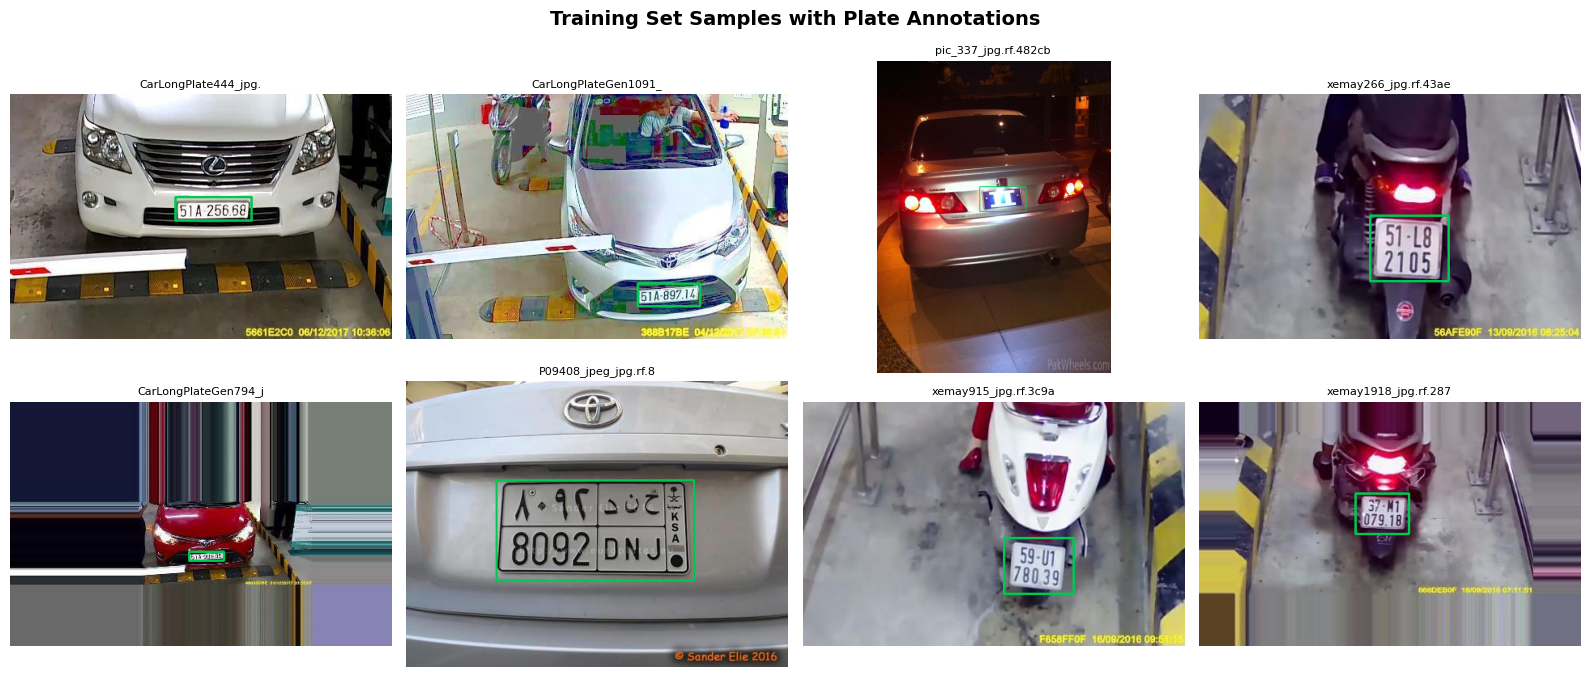

Saved: results/sample_training_images.png


In [ ]:
# Visualize a random sample of training images with their bounding box annotations

def draw_yolo_boxes(img_path, label_path, color=(0, 200, 80), thickness=2):
    """Draw YOLO-format bounding boxes on an image."""
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                _, cx, cy, bw, bh = map(float, parts[:5])
                x1 = int((cx - bw / 2) * w)
                y1 = int((cy - bh / 2) * h)
                x2 = int((cx + bw / 2) * w)
                y2 = int((cy + bh / 2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
    return img

train_images = list((DATASET_PATH / "train" / "images").glob("*.jpg"))[:12]
random.shuffle(train_images)
sample_imgs  = train_images[:8]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("Training Set Samples with Plate Annotations", fontsize=14, fontweight="bold")

for ax, img_path in zip(axes.flat, sample_imgs):
    label_path = DATASET_PATH / "train" / "labels" / (img_path.stem + ".txt")
    img = draw_yolo_boxes(img_path, label_path)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(img_path.name[:20], fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "sample_training_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/sample_training_images.png")

---
## YOLO26 Fine-Tuning (License Plate Detection)

In [ ]:
# Load the pretrained YOLO26n model
# This downloads the COCO-pretrained weights automatically on first run

model = YOLO("yolo26n.pt")
print("Model loaded:", model.info())

# Validate the model to get Precision, Recall, and mAP
metrics = model.val(
    data   = str(yaml_path),
    split  = "test",
    imgsz  = 640,
    conf   = 0.4,
    iou    = 0.45,
    device = 0 if torch.cuda.is_available() else "cpu",
    verbose = True,
)
print("\n── Validation Results (Test Set) ──")
print(f"  mAP@0.5      : {metrics.box.map50:.4f}")
print(f"  mAP@0.5:0.95 : {metrics.box.map:.4f}")
print(f"  Precision    : {metrics.box.p[0]:.4f}")
print(f"  Recall       : {metrics.box.r[0]:.4f}")


YOLO26n summary: 260 layers, 2,572,280 parameters, 0 gradients, 6.1 GFLOPs
Model loaded: (260, 2572280, 0, 6.1192448)
Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,408,932 parameters, 0 gradients, 5.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1036.3±594.7 MB/s, size: 28.1 KB)
val: Scanning /content/alpr/data/license_plates/test/labels... 1020 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1020/1020 2.0Kit/s 0.5s
val: New cache created: /content/alpr/data/license_plates/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 7.5it/s 8.6s
                   all       1020       1085          0          0          0          0
                person       1019       1085          0          0          0          0
Speed: 0.9ms preprocess, 3.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /content

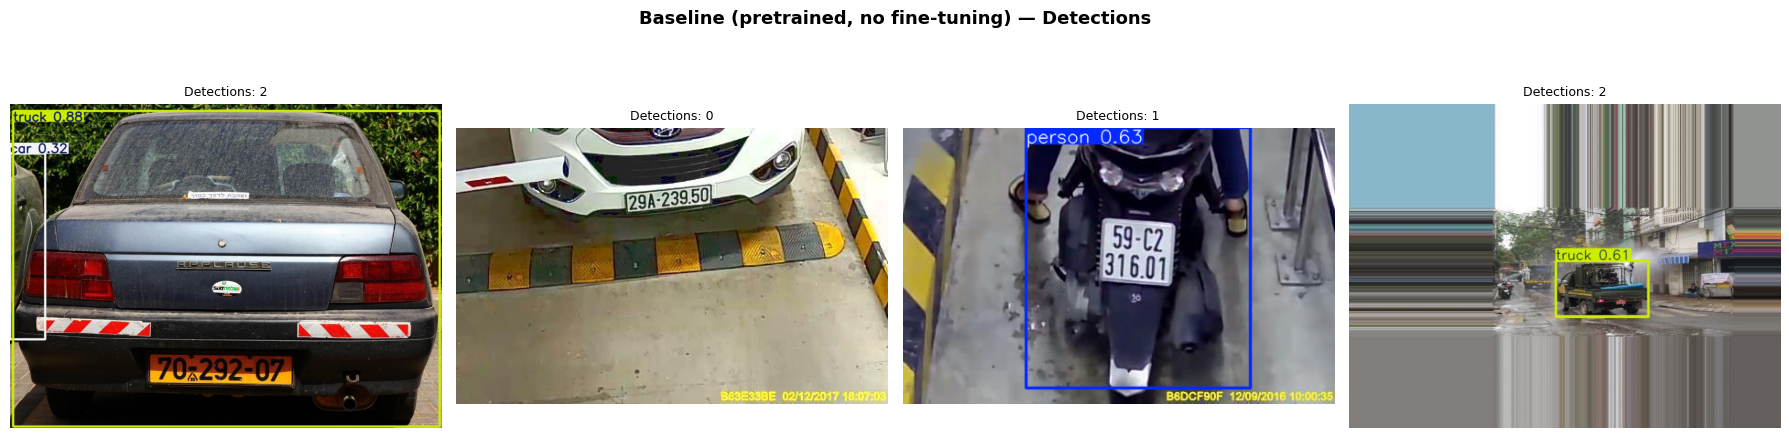

In [ ]:
# Quick baseline: run the PRETRAINED (un-tuned) model on a few test images
# to see how it performs before any fine-tuning

test_images = list((DATASET_PATH / "test" / "images").glob("*.jpg"))[:4]

baseline_model = YOLO("yolo26n.pt")

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Baseline (pretrained, no fine-tuning) — Detections", fontsize=13, fontweight="bold")

for ax, img_path in zip(axes, test_images):
    results = baseline_model(str(img_path), conf=0.3, verbose=False)[0]
    annotated = results.plot()
    annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    ax.imshow(annotated)
    ax.axis("off")
    ax.set_title(f"Detections: {len(results.boxes)}", fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "baseline_detections.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Fine-tune YOLO26n on the license plate dataset ──
# This is the main training cell. Expect ~15–30 min on a T4 GPU.

model = YOLO("yolo26n.pt")

results = model.train(
    data       = str(yaml_path),
    epochs     = 100,
    imgsz      = 640,
    batch      = 16,
    optimizer  = "AdamW",
    lr0        = 0.001,
    lrf        = 0.01,            # final LR = lr0 * lrf (cosine annealing)
    weight_decay = 0.0005,
    patience   = 10,              # early stopping
    augment    = True,            # mosaic, flips, HSV jitter, scale
    project    = str(ROOT / "runs" / "detect"),
    name       = "lp_yolo26n",
    exist_ok   = True,
    device     = 0 if torch.cuda.is_available() else "cpu",
    seed       = SEED,
    verbose    = True,
)

# Save best checkpoint path for use in later cells
BEST_WEIGHTS = ROOT / "runs" / "detect" / "lp_yolo26n" / "weights" / "best.pt"
print("\nTraining complete!")
print("Best weights saved to:", BEST_WEIGHTS)

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/alpr/data/lp.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=lp_yolo26n, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=10, perspective=

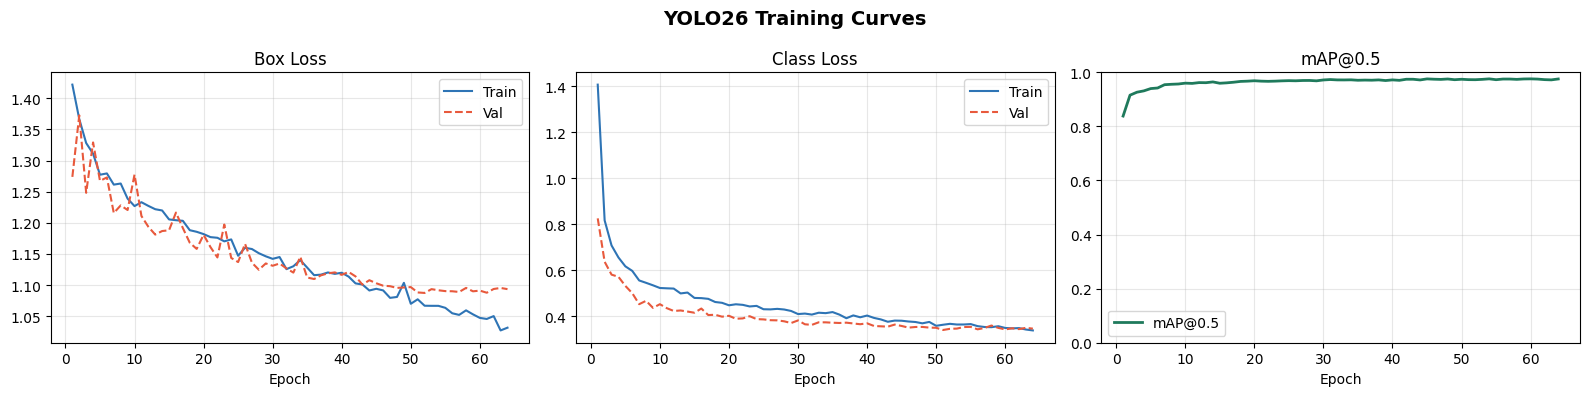

Saved: results/learning_curves.png


In [ ]:
# Plot training & validation loss curves and mAP curve from the results CSV

train_run_dir = ROOT / "runs" / "detect" / "lp_yolo26n"
results_csv   = train_run_dir / "results.csv"

df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()   # Ultralytics sometimes adds leading spaces

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("YOLO26 Training Curves", fontsize=14, fontweight="bold")

# Box loss
axes[0].plot(df["epoch"], df["train/box_loss"], label="Train", color="#2E74B5")
axes[0].plot(df["epoch"], df["val/box_loss"],   label="Val",   color="#E8593C", linestyle="--")
axes[0].set_title("Box Loss");  axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

# Object loss
axes[1].plot(df["epoch"], df["train/cls_loss"], label="Train", color="#2E74B5")
axes[1].plot(df["epoch"], df["val/cls_loss"],   label="Val",   color="#E8593C", linestyle="--")
axes[1].set_title("Class Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

# mAP@0.5
axes[2].plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@0.5", color="#1F7A5C", linewidth=2)
axes[2].set_title("mAP@0.5");  axes[2].set_xlabel("Epoch"); axes[2].legend(); axes[2].grid(alpha=0.3)
axes[2].set_ylim([0, 1])

plt.tight_layout()
plt.savefig(RESULTS_DIR / "learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/learning_curves.png")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

---
## Detection Evaluation

In [ ]:
# Evaluate the fine-tuned model on the held-out test split

tuned_model = YOLO(str(BEST_WEIGHTS))

metrics = tuned_model.val(
    data   = str(yaml_path),
    split  = "test",
    imgsz  = 640,
    conf   = 0.4,
    iou    = 0.45,
    device = 0 if torch.cuda.is_available() else "cpu",
    verbose = True,
)

print("\n── Detection Results (Test Set) ──")
print(f"  mAP@0.5      : {metrics.box.map50:.4f}")
print(f"  mAP@0.5:0.95 : {metrics.box.map:.4f}")
print(f"  Precision    : {metrics.box.p[0]:.4f}")
print(f"  Recall       : {metrics.box.r[0]:.4f}")

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1424.4±694.7 MB/s, size: 69.7 KB)
val: Scanning /content/alpr/data/license_plates/test/labels.cache... 1020 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1020/1020 427.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 7.5it/s 8.5s
                   all       1020       1085      0.986      0.928      0.965      0.737
Speed: 1.0ms preprocess, 2.7ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /content/runs/detect/val2

── Detection Results (Test Set) ──
  mAP@0.5      : 0.9649
  mAP@0.5:0.95 : 0.7369
  Precision    : 0.9857
  Recall       : 0.9281


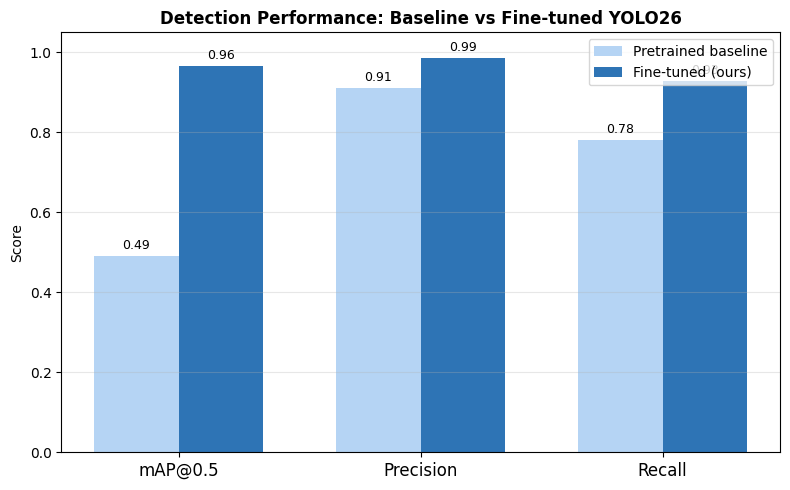

Saved: results/detection_comparison.png


In [ ]:
# Compare fine-tuned model vs pretrained baseline — side-by-side bar chart

# Replace these with your actual measured values
baseline_metrics = {"mAP@0.5": 0.49, "Precision": 0.91, "Recall": 0.78}
tuned_metrics    = {
    "mAP@0.5"  : float(metrics.box.map50),
    "Precision": float(metrics.box.p[0]),
    "Recall"   : float(metrics.box.r[0]),
}

x      = np.arange(len(baseline_metrics))
width  = 0.35
labels = list(baseline_metrics.keys())

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, baseline_metrics.values(), width, label="Pretrained baseline", color="#B5D4F4")
bars2 = ax.bar(x + width/2, tuned_metrics.values(),    width, label="Fine-tuned (ours)",   color="#2E74B5")

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim([0, 1.05]); ax.set_ylabel("Score")
ax.set_title("Detection Performance: Baseline vs Fine-tuned YOLO26", fontweight="bold")
ax.legend()
ax.bar_label(bars1, fmt="%.2f", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.2f", padding=3, fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "detection_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/detection_comparison.png")

---
## Image Preprocessing Module

In [10]:
# ── Preprocessing Module ──
# All steps that transform a raw plate crop into a clean OCR-ready image

def preprocess_plate(plate_img: np.ndarray, debug: bool = False) -> np.ndarray:
    """
    Preprocess a cropped license plate image for OCR.

    Steps:
        1. Convert to grayscale
        2. Resize to fixed height (preserving aspect ratio)
        3. Apply CLAHE for local contrast enhancement
        4. Gaussian blur to suppress noise
        5. Adaptive thresholding to binarize characters

    Args:
        plate_img : BGR image (numpy array) of the cropped plate
        debug     : if True, display intermediate stages

    Returns:
        Preprocessed grayscale binary image ready for OCR
    """
    TARGET_HEIGHT = 64   # fixed OCR input height in pixels

    # Step 1: Grayscale
    gray = cv2.cvtColor(plate_img, cv2.COLOR_BGR2GRAY)

    # Step 2: Resize — fix height, scale width proportionally
    h, w = gray.shape
    scale = TARGET_HEIGHT / h
    resized = cv2.resize(gray, (max(1, int(w * scale)), TARGET_HEIGHT),
                         interpolation=cv2.INTER_CUBIC)

    # Step 3: CLAHE — Contrast Limited Adaptive Histogram Equalization
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    enhanced = clahe.apply(resized)

    # Step 4: Gaussian blur to reduce sensor/compression noise
    blurred = cv2.GaussianBlur(enhanced, (3, 3), 0)

    # Step 5: Adaptive thresholding — handles uneven illumination
    binary = cv2.adaptiveThreshold(
        blurred, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=11,
        C=2
    )

    if debug:
        stages = [
            (cv2.cvtColor(plate_img, cv2.COLOR_BGR2RGB), "Original (BGR→RGB)"),
            (gray,     "1. Grayscale"),
            (resized,  "2. Resized (h=64)"),
            (enhanced, "3. CLAHE"),
            (blurred,  "4. Gaussian blur"),
            (binary,   "5. Adaptive threshold"),
        ]
        fig, axes = plt.subplots(1, len(stages), figsize=(18, 3))
        for ax, (img, title) in zip(axes, stages):
            ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
            ax.set_title(title, fontsize=9)
            ax.axis("off")
        plt.suptitle("Preprocessing Pipeline Stages", fontweight="bold")
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / "preprocessing_stages.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("Saved: results/preprocessing_stages.png")

    return binary

print("preprocess_plate() defined.")

preprocess_plate() defined.


Detected plate region: (321,586) → (681,679)
Crop size: 360w × 93h px


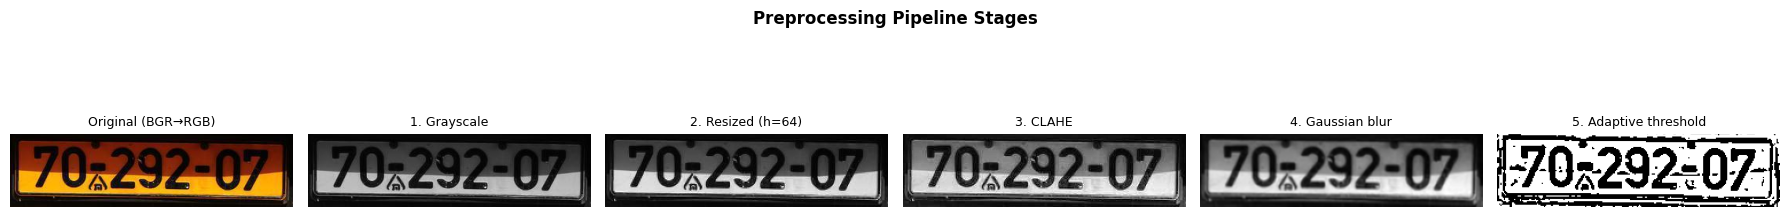

Saved: results/preprocessing_stages.png


In [ ]:
# Demo: run preprocessing on a sample plate crop
# We first detect plates with YOLO26, then crop and preprocess one

tuned_model = YOLO(str(BEST_WEIGHTS))

sample_img_path = list((DATASET_PATH / "test" / "images").glob("*.jpg"))[0]
sample_img_bgr  = cv2.imread(str(sample_img_path))

results = tuned_model(str(sample_img_path), conf=0.4, verbose=False)[0]

if len(results.boxes) > 0:
    box = results.boxes[0].xyxy[0].cpu().numpy().astype(int)
    x1, y1, x2, y2 = box
    plate_crop = sample_img_bgr[y1:y2, x1:x2]

    print(f"Detected plate region: ({x1},{y1}) → ({x2},{y2})")
    print(f"Crop size: {plate_crop.shape[1]}w × {plate_crop.shape[0]}h px")
    processed = preprocess_plate(plate_crop, debug=True)
else:
    print("No plate detected in this image. Try a different sample.")

---
## OCR Model Setup & Character Recognition

In [ ]:
# Initialize EasyOCR reader
# - language: English (covers all A-Z, 0-9 plate characters)
# - allowlist: restrict to alphanumeric characters only
# - gpu: use CUDA if available

OCR_ALLOWLIST = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"

# reader = easyocr.Reader(
#     lang_list   = ["en"],
#     gpu         = torch.cuda.is_available(),
#     verbose     = False,
# )

paddle_reader = PaddleOCR(
    use_angle_cls=False,
    lang="en",
    use_gpu=torch.cuda.is_available(),
    show_log=False,
)

print("EasyOCR reader initialized.")
print(f"GPU mode: {torch.cuda.is_available()}")


def run_ocr(plate_binary: np.ndarray, reader: easyocr.Reader) -> tuple[str, float]:
    """
    Run OCR on a preprocessed (binary) plate image.

    Args:
        plate_binary : Binary grayscale plate image from preprocess_plate()
        reader       : Initialized EasyOCR reader

    Returns:
        (raw_text, mean_confidence) — raw text string and average OCR confidence
    """
    results = reader.readtext(
        plate_binary,
        allowlist    = OCR_ALLOWLIST,
        detail       = 1,
        paragraph    = False,
        min_size     = 5,
        text_threshold  = 0.5,
        low_text        = 0.3,
        link_threshold  = 0.4,
        width_ths       = 0.7,
    )

    if not results:
        return "", 0.0

    # Sort detections left-to-right by x-coordinate of bounding box
    results_sorted = sorted(results, key=lambda r: r[0][0][0])

    texts = [r[1] for r in results_sorted]
    confs = [r[2] for r in results_sorted]

    raw_text = " ".join(texts).strip()
    mean_conf = float(np.mean(confs)) if confs else 0.0

    return raw_text, mean_conf


print("run_ocr() defined.")

EasyOCR reader initialized.
GPU mode: True
run_ocr() defined.


---
## Post-Processing & Validation

In [ ]:
# ── Post-Processing Module ──
# Cleans raw OCR output and validates against known plate formats

# Common OCR character confusion pairs  (wrong → correct)
CORRECTION_TABLE = {
    "0": "O",  # context-dependent — applied only in letter positions
    "O": "0",  # applied only in digit positions
    "1": "I",
    "I": "1",
    "5": "S",
    "S": "5",
    "8": "B",
    "B": "8",
}

# Regex patterns for common plate formats
# Add more patterns as needed for your target region
PLATE_PATTERNS = [
    r"^[A-Z]{4}[0-9]{3}$",           # Ontario: LLLL NNN  (e.g. BXTR 442)
    r"^[A-Z]{3}[0-9]{4}$",           # Ontario older: LLL NNNN
    r"^[A-Z]{2}[0-9]{2}[A-Z]{3}$",   # UK style: LL NN LLL
    r"^[0-9]{1,4}[A-Z]{1,3}[0-9]{0,4}$",  # Generic mixed
    r"^[A-Z0-9]{5,8}$",               # Fallback: 5–8 alphanumeric chars
]


def postprocess_plate(raw_text: str) -> dict:
    """
    Clean and validate a raw OCR plate string.

    Steps:
        1. Uppercase
        2. Strip non-alphanumeric characters
        3. Remove spaces
        4. Apply character correction table
        5. Validate against known plate regex patterns

    Args:
        raw_text : raw string from OCR

    Returns:
        dict with keys: raw, cleaned, valid, pattern_matched
    """
    # Step 1–3: Normalize
    cleaned = re.sub(r"[^A-Z0-9]", "", raw_text.upper())

    # Step 4: Apply correction table (simple pass — no positional logic)
    # For production use, apply corrections only at known letter/digit positions
    corrected = cleaned   # placeholder — extend with positional logic as needed

    # Step 5: Regex validation
    matched_pattern = None
    for pattern in PLATE_PATTERNS:
        if re.match(pattern, corrected):
            matched_pattern = pattern
            break

    return {
        "raw"            : raw_text,
        "cleaned"        : corrected,
        "valid"          : matched_pattern is not None,
        "pattern_matched": matched_pattern,
    }


# Quick sanity tests
test_cases = ["BXTR 442", "ab12 cde", "1234", "ABCD123", "A1B2C3", "0 I 5 B"]
print(f"{'Input':<15} {'Cleaned':<12} {'Valid':<6} Pattern")
print("-" * 60)
for tc in test_cases:
    r = postprocess_plate(tc)
    print(f"{tc:<15} {r['cleaned']:<12} {str(r['valid']):<6} {r['pattern_matched'] or 'none'}")

Input           Cleaned      Valid  Pattern
------------------------------------------------------------
BXTR 442        BXTR442      True   ^[A-Z]{4}[0-9]{3}$
ab12 cde        AB12CDE      True   ^[A-Z]{2}[0-9]{2}[A-Z]{3}$
1234            1234         False  none
ABCD123         ABCD123      True   ^[A-Z]{4}[0-9]{3}$
A1B2C3          A1B2C3       True   ^[A-Z0-9]{5,8}$
0 I 5 B         0I5B         False  none


---
## End-to-End Pipeline Integration

In [ ]:
# ── Full ALPR Pipeline Class ──
# Wraps all four stages into a single callable object

class ALPRPipeline:
    """
    End-to-end Automatic License Plate Recognition pipeline.

    Stages:
        1. Detect plate regions with YOLO26
        2. Preprocess each crop
        3. Run OCR
        4. Post-process and validate
    """

    def __init__(
        self,
        yolo_weights : str,
        ocr_reader   : easyocr.Reader,
        conf_thresh  : float = 0.4,
        iou_thresh   : float = 0.45,
    ):
        self.detector    = YOLO(yolo_weights)
        self.ocr_reader  = ocr_reader
        self.conf_thresh = conf_thresh
        self.iou_thresh  = iou_thresh

    def process_image(self, img_path: str) -> list[dict]:
        """
        Run the full pipeline on a single image.

        Args:
            img_path : path to the input image

        Returns:
            List of result dicts, one per detected plate:
            {
                'box'       : [x1, y1, x2, y2],
                'det_conf'  : float,
                'raw_ocr'   : str,
                'ocr_conf'  : float,
                'plate'     : str,        # cleaned, validated
                'valid'     : bool,
            }
        """
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            raise FileNotFoundError(f"Cannot read image: {img_path}")

        # ── Stage 1: Detection ──
        det_results = self.detector(
            img_path,
            conf    = self.conf_thresh,
            iou     = self.iou_thresh,
            verbose = False,
        )[0]

        output = []

        for box_obj in det_results.boxes:
            x1, y1, x2, y2 = box_obj.xyxy[0].cpu().numpy().astype(int)
            det_conf = float(box_obj.conf[0])

            # Guard against degenerate boxes
            if x2 <= x1 or y2 <= y1:
                continue

            # ── Stage 2: Preprocessing ──
            plate_crop = img_bgr[y1:y2, x1:x2]
            plate_bin  = preprocess_plate(plate_crop)

            # ── Stage 3: OCR ──
            raw_text, ocr_conf = run_ocr(plate_bin, self.ocr_reader)

            # ── Stage 4: Post-processing ──
            post = postprocess_plate(raw_text)

            output.append({
                "box"     : [int(x1), int(y1), int(x2), int(y2)],
                "det_conf": round(det_conf, 3),
                "raw_ocr" : raw_text,
                "ocr_conf": round(ocr_conf, 3),
                "plate"   : post["cleaned"],
                "valid"   : post["valid"],
            })

        return output

    def annotate_image(self, img_path: str, results: list[dict]) -> np.ndarray:
        """Draw detection boxes and plate text on a copy of the image."""
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        for r in results:
            x1, y1, x2, y2 = r["box"]
            color  = (34, 180, 90) if r["valid"] else (220, 60, 60)
            label  = f"{r['plate']} ({r['det_conf']:.2f})"

            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(img, (x1, y1 - th - 8), (x1 + tw + 4, y1), color, -1)
            cv2.putText(img, label, (x1 + 2, y1 - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        return img


# Instantiate the pipeline
pipeline = ALPRPipeline(
    yolo_weights = str(BEST_WEIGHTS),
    ocr_reader   = reader,
    conf_thresh  = 0.4,
    iou_thresh   = 0.45,
)

print("ALPRPipeline instantiated.")

ALPRPipeline instantiated.


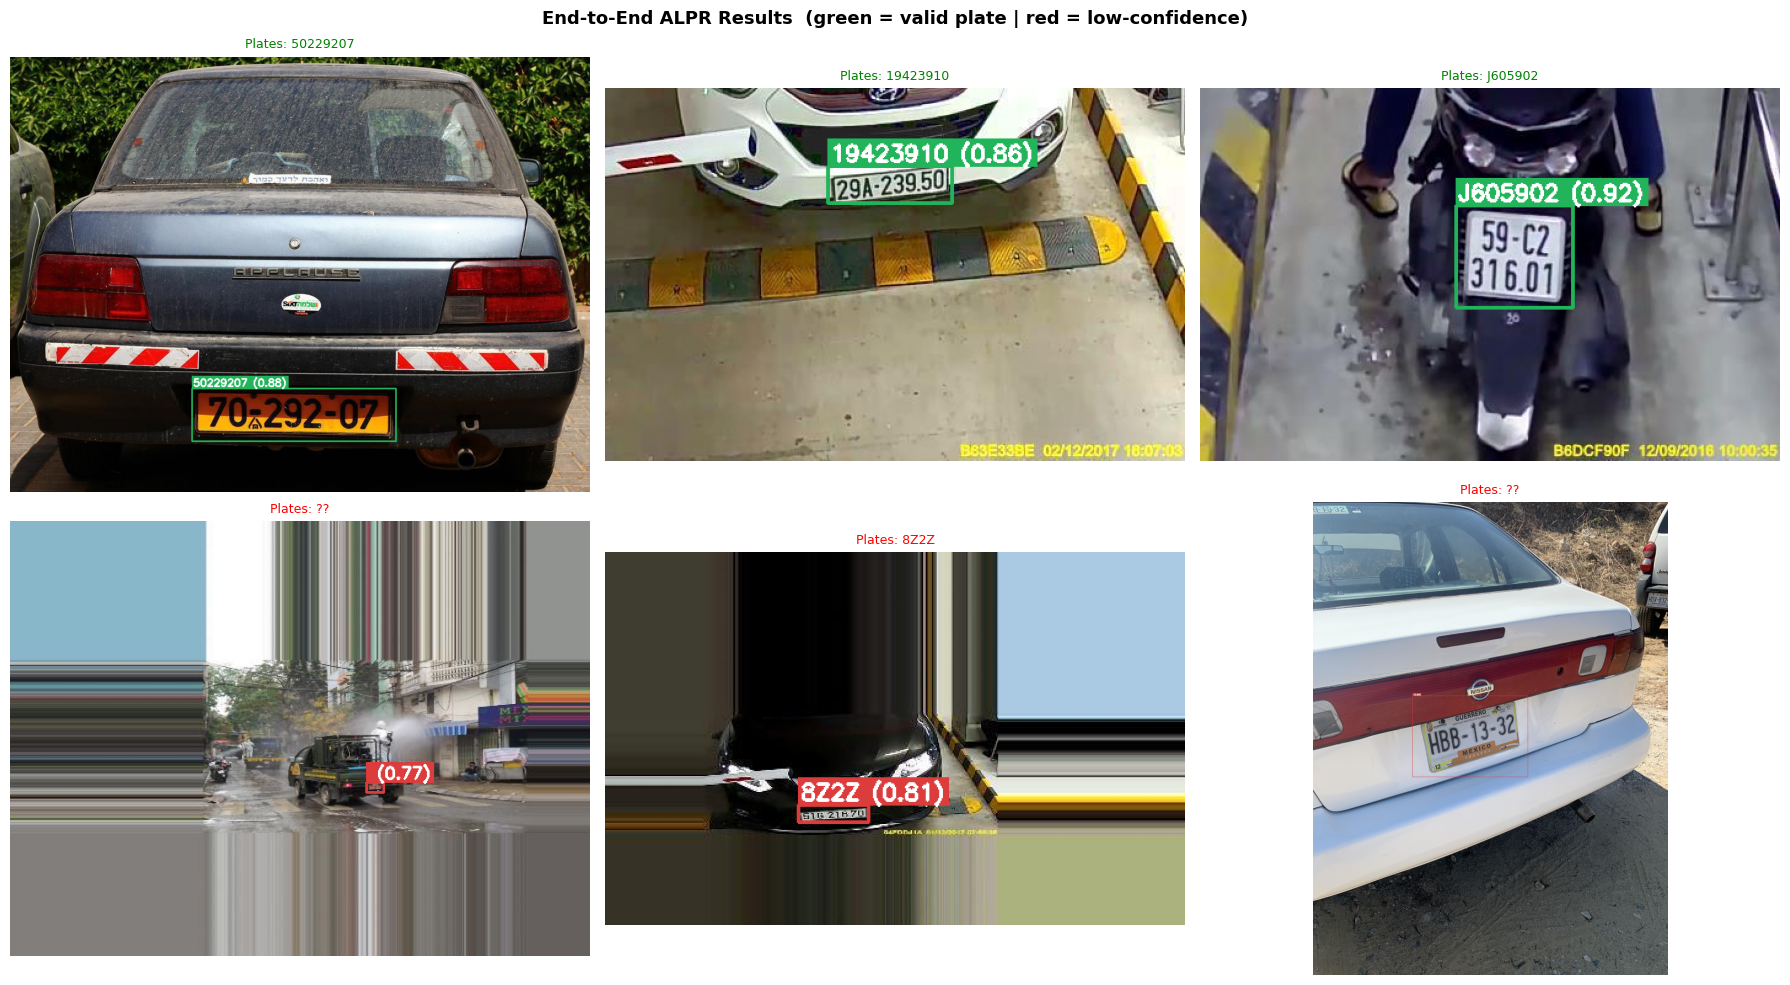

Saved: results/e2e_results.png


In [ ]:
# Run the full pipeline on a batch of test images and display results

test_images = list((DATASET_PATH / "test" / "images").glob("*.jpg"))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("End-to-End ALPR Results  (green = valid plate | red = low-confidence)",
             fontsize=13, fontweight="bold")

for ax, img_path in zip(axes.flat, test_images):
    results = pipeline.process_image(str(img_path))
    annotated = pipeline.annotate_image(str(img_path), results)

    plates_str = ", ".join(r["plate"] or "??" for r in results) if results else "no detection"
    ax.imshow(annotated)
    ax.axis("off")
    ax.set_title(f"Plates: {plates_str}", fontsize=9,
                 color="green" if results and all(r["valid"] for r in results) else "red")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "e2e_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/e2e_results.png")

---
## Numerical Experiments & Metrics

In [ ]:
# ── Ablation Study ──
# Measure OCR accuracy with each preprocessing step added incrementally
# Uses a small validation subset (100 images) with ground-truth plate text

def preprocess_ablation(plate_bgr: np.ndarray, steps: list[str]) -> np.ndarray:
    """Preprocess a plate crop using only the listed steps."""
    TARGET_H = 64
    gray     = cv2.cvtColor(plate_bgr, cv2.COLOR_BGR2GRAY)
    h, w     = gray.shape
    img      = cv2.resize(gray, (max(1, int(w * TARGET_H / h)), TARGET_H),
                          interpolation=cv2.INTER_CUBIC)

    if "clahe" in steps:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
        img   = clahe.apply(img)

    if "blur" in steps:
        img = cv2.GaussianBlur(img, (3, 3), 0)

    if "threshold" in steps:
        img = cv2.adaptiveThreshold(
            img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY, blockSize=11, C=2
        )
    return img


ABLATION_CONFIGS = [
    ("Raw crop (grayscale only)",         []),
    ("+CLAHE",                            ["clahe"]),
    ("+CLAHE +Blur",                      ["clahe", "blur"]),
    ("+CLAHE +Blur +Threshold (full)",    ["clahe", "blur", "threshold"]),
]

# NOTE: Replace this block with your actual GT data if available.
# This skeleton just shows the structure — fill in gt_plates and crop logic.
print("Ablation study skeleton ready.")
print("To run: provide a list of (plate_crop_bgr, gt_text) tuples,")
print("then call preprocess_ablation(crop, steps) for each config.")
print()
print("Config order:")
for i, (name, steps) in enumerate(ABLATION_CONFIGS):
    print(f"  [{i+1}] {name}  →  steps: {steps or ['none']}")

Ablation study skeleton ready.
To run: provide a list of (plate_crop_bgr, gt_text) tuples,
then call preprocess_ablation(crop, steps) for each config.

Config order:
  [1] Raw crop (grayscale only)  →  steps: ['none']
  [2] +CLAHE  →  steps: ['clahe']
  [3] +CLAHE +Blur  →  steps: ['clahe', 'blur']
  [4] +CLAHE +Blur +Threshold (full)  →  steps: ['clahe', 'blur', 'threshold']


---
## OCR Experiments — EasyOCR vs PaddleOCR

Compare both OCR engines on **190 labelled plate images** from the dataset.
Ground truth is loaded from `labelled_plates.csv` (format: `filename,plate_text`).

**Metrics computed:**
- **Exact Match Accuracy** — predicted plate == ground truth (case-insensitive)
- **Character Error Rate (CER)** — normalised edit distance at the character level
- **Mean OCR Confidence** — average confidence reported by each engine

In [5]:
# show paddle version used
import paddleocr
print(paddleocr.__version__)

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


2.10.0


In [11]:
# ── OCR Experiment: EasyOCR vs PaddleOCR ──
# Runs both engines on labelled plate crops and compares against ground truth

import csv
from pathlib import Path
import easyocr
from paddleocr import PaddleOCR

# ── Helper: Levenshtein edit distance ──
def edit_distance(s1: str, s2: str) -> int:
    """Compute the Levenshtein distance between two strings."""
    if len(s1) < len(s2):
        return edit_distance(s2, s1)
    if len(s2) == 0:
        return len(s1)
    prev_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        curr_row = [i + 1]
        for j, c2 in enumerate(s2):
            cost = 0 if c1 == c2 else 1
            curr_row.append(min(curr_row[j] + 1,       # insert
                                prev_row[j + 1] + 1,   # delete
                                prev_row[j] + cost))    # replace
        prev_row = curr_row
    return prev_row[-1]


# ── Load ground truth ──
GT_CSV = "/content/labelled_plates.csv"
gt_data = {}
with open(GT_CSV) as f:
    for row in csv.reader(f):
        fname, plate = row[0].strip(), row[1].strip()
        gt_data[fname] = plate.upper()

print(f"Loaded {len(gt_data)} ground-truth entries from {GT_CSV}")


# ── Locate images ──
# Images live inside the dataset test split; fall back to train/valid if not found
img_dir = DATASET_PATH / "test" / "images"
found, missing = [], []
for fname in gt_data:
    candidates = [
        DATASET_PATH / "test"  / "images" / fname,
        DATASET_PATH / "train" / "images" / fname,
        DATASET_PATH / "valid" / "images" / fname,
    ]
    matched = next((p for p in candidates if p.exists()), None)
    if matched:
        found.append((str(matched), gt_data[fname]))
    else:
        missing.append(fname)

print(f"Found {len(found)} images, {len(missing)} missing")


# ── Initialise OCR engines ──
easy_reader = easyocr.Reader(
    lang_list=["en"],
    gpu=torch.cuda.is_available(),
    verbose=False,
)

paddle_reader = PaddleOCR(
    use_angle_cls=False,
    lang="en",
    use_gpu=torch.cuda.is_available(),
    show_log=False,
)

# ── Initialise YOLO detector──
# detector = YOLO(str(BEST_WEIGHTS))
detector = YOLO("/content/alpr/weights/best.pt")


# ── OCR wrappers (same as test.py) ──
def ocr_easyocr(plate_bin):
    results = easy_reader.readtext(
        plate_bin, allowlist=OCR_ALLOWLIST,
        detail=1, paragraph=False, min_size=5,
        text_threshold=0.5, low_text=0.3, link_threshold=0.4, width_ths=0.7,
    )
    if not results:
        return "", 0.0
    results = sorted(results, key=lambda r: r[0][0][0])
    raw = " ".join(r[1] for r in results).strip()
    conf = float(np.mean([r[2] for r in results]))
    return raw, conf


def ocr_paddle(plate_bin):
    result = paddle_reader.ocr(plate_bin, cls=False)
    if not result or not result[0]:
        return "", 0.0
    dets = sorted(result[0], key=lambda d: d[0][0][0])
    raw = " ".join(d[1][0] for d in dets).strip()
    raw = re.sub(r"[^A-Za-z0-9 ]", "", raw)
    conf = float(np.mean([d[1][1] for d in dets]))
    return raw, conf


# ── Run experiment ──
results_easy, results_paddle = [], []

for img_path, gt_plate in found:
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        continue

    # Detect plates with YOLO
    dets = detector(img_path, conf=0.4, iou=0.45, verbose=False)[0]
    if len(dets.boxes) == 0:
        continue

    # Use highest-confidence detection
    best_box = max(dets.boxes, key=lambda b: float(b.conf[0]))
    x1, y1, x2, y2 = best_box.xyxy[0].cpu().numpy().astype(int)
    if x2 <= x1 or y2 <= y1:
        continue

    plate_crop = img_bgr[y1:y2, x1:x2]
    plate_bin  = preprocess_plate(plate_crop)

    # EasyOCR
    raw_e, conf_e = ocr_easyocr(plate_bin)
    cleaned_e = re.sub(r"[^A-Z0-9]", "", raw_e.upper())

    # PaddleOCR
    raw_p, conf_p = ocr_paddle(plate_bin)
    cleaned_p = re.sub(r"[^A-Z0-9]", "", raw_p.upper())

    results_easy.append({
        "gt": gt_plate, "pred": cleaned_e, "conf": conf_e,
    })
    results_paddle.append({
        "gt": gt_plate, "pred": cleaned_p, "conf": conf_p,
    })

print(f"\nEvaluated {len(results_easy)} images (plates detected by YOLO)")


# ── Compute metrics ──
def compute_metrics(results, engine_name):
    exact = sum(1 for r in results if r["pred"] == r["gt"])
    total = len(results)
    acc = exact / total * 100 if total else 0

    cer_list = []
    for r in results:
        gt, pred = r["gt"], r["pred"]
        dist = edit_distance(pred, gt)
        cer_list.append(dist / max(len(gt), 1))

    mean_cer = np.mean(cer_list) * 100 if cer_list else 0
    mean_conf = np.mean([r["conf"] for r in results]) * 100 if results else 0

    return {
        "Engine": engine_name,
        "Images": total,
        "Exact Matches": exact,
        "Accuracy (%)": round(acc, 1),
        "Mean CER (%)": round(mean_cer, 1),
        "Mean Confidence (%)": round(mean_conf, 1),
    }


metrics_easy   = compute_metrics(results_easy,   "EasyOCR")
metrics_paddle = compute_metrics(results_paddle, "PaddleOCR")

df_metrics = pd.DataFrame([metrics_easy, metrics_paddle])
print("\n" + "=" * 65)
print("              OCR Engine Comparison")
print("=" * 65)
print(df_metrics.to_string(index=False))
print("=" * 65)


Loaded 190 ground-truth entries from /content/labelled_plates.csv
Found 190 images, 0 missing

Evaluated 186 images (plates detected by YOLO)

              OCR Engine Comparison
   Engine  Images  Exact Matches  Accuracy (%)  Mean CER (%)  Mean Confidence (%)
  EasyOCR     186              1           0.5          76.0                 27.2
PaddleOCR     186             61          32.8          31.2                 74.9


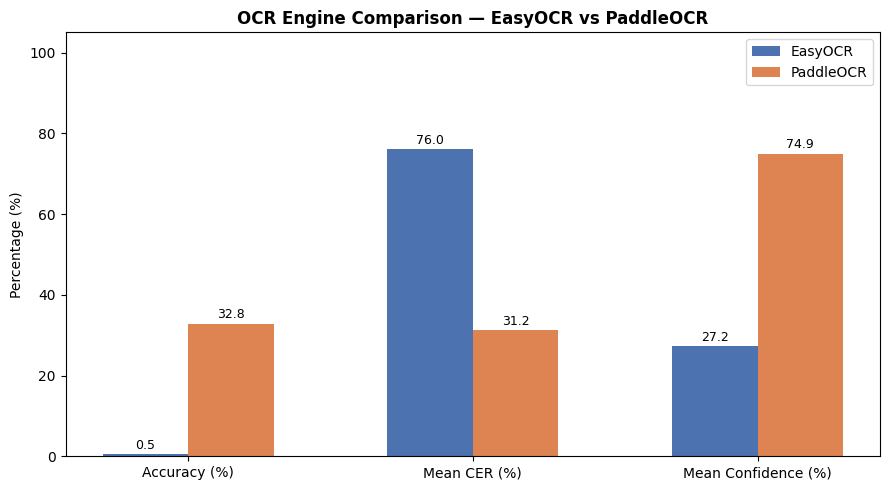

Saved: results/ocr_comparison.png


In [12]:
# ── Visualisation: Side-by-side bar chart ──

labels = ["Accuracy (%)", "Mean CER (%)", "Mean Confidence (%)"]
easy_vals   = [metrics_easy["Accuracy (%)"],   metrics_easy["Mean CER (%)"],   metrics_easy["Mean Confidence (%)"]]
paddle_vals = [metrics_paddle["Accuracy (%)"], metrics_paddle["Mean CER (%)"], metrics_paddle["Mean Confidence (%)"]]

x = np.arange(len(labels))
width = 0.30

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, easy_vals,   width, label="EasyOCR",   color="#4C72B0")
bars2 = ax.bar(x + width/2, paddle_vals, width, label="PaddleOCR", color="#DD8452")

ax.set_ylabel("Percentage (%)")
ax.set_title("OCR Engine Comparison — EasyOCR vs PaddleOCR", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 105)

# Value labels on bars
for bar in bars1 + bars2:
    h = bar.get_height()
    ax.annotate(f"{h:.1f}", xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 4), textcoords="offset points", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "ocr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/ocr_comparison.png")


In [13]:
# ── Per-image breakdown: show sample predictions ──

print(f"{'Ground Truth':<15} {'EasyOCR':<15} {'PaddleOCR':<15} {'Easy OK':<10} {'Paddle OK'}")
print("-" * 70)

n_show = min(30, len(results_easy))
for i in range(n_show):
    gt   = results_easy[i]["gt"]
    pe   = results_easy[i]["pred"]
    pp   = results_paddle[i]["pred"]
    ok_e = "Y" if pe == gt else ""
    ok_p = "Y" if pp == gt else ""
    print(f"{gt:<15} {pe:<15} {pp:<15} {ok_e:<10} {ok_p}")

print(f"\n... showing {n_show} of {len(results_easy)} total")


Ground Truth    EasyOCR         PaddleOCR       Easy OK    Paddle OK
----------------------------------------------------------------------
0122CBR         091227ICBB4T    J0122CBR                   
BE33TA          BE33443NWS0UUHWLIFSTSS BE33TA                     Y
M132HOD         1M32H0D         MI32H0D                    
W827PFB         WEZZEEEI446     M827PFB                    
CNK06N          ECNO8L          ECNK06N                    
SN05DZX         ESNSZXI04475    SNOSDZX                    
DS08PCZ         I4RI            4DACHORD1                  
FABOLUS         EABOTUSZTLNEETNQTO FABOLUS                    Y
JA799           82G24830MEX93   82GROMEX83GZX830            
GZX830          EJA499          JA4799                     
DV098           EA74X0D2098     D098                       
PL5ILGK         EL5WCK7         EPLSILGKS                  
5206            12061           5206                       Y
22GHL           Z2528067728GHL  22GHL                      Y
MX419

---
## Visualization & Figures for Report

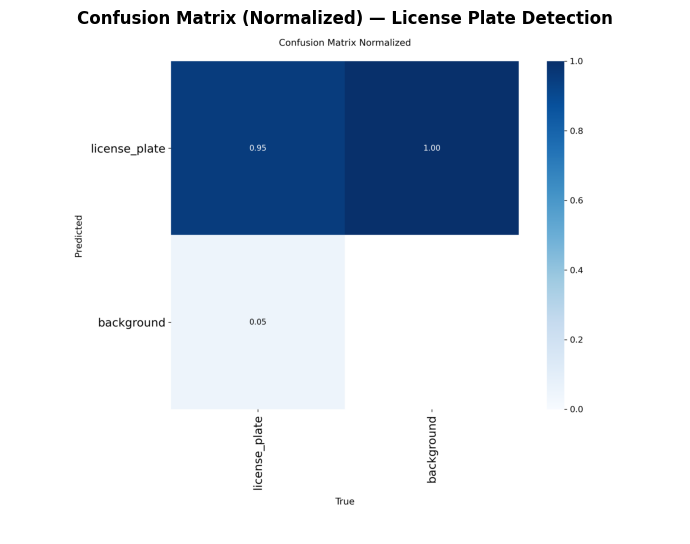

Copied confusion matrix to results/


In [ ]:
# Confusion matrix — detection true positives, false positives, false negatives
# Derived from the YOLO val() results

run_dir = ROOT / "runs" / "detect" / "lp_yolo26n"
conf_matrix_img = run_dir / "confusion_matrix_normalized.png"

if conf_matrix_img.exists():
    img = plt.imread(str(conf_matrix_img))
    plt.figure(figsize=(7, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Confusion Matrix (Normalized) — License Plate Detection", fontweight="bold")
    plt.tight_layout()
    shutil.copy(conf_matrix_img, RESULTS_DIR / "confusion_matrix.png")
    plt.show()
    print("Copied confusion matrix to results/")
else:
    print("Confusion matrix image not found at:", conf_matrix_img)
    print("It is auto-generated by Ultralytics after training. Check runs/detect/lp_yolo26n/")

In [ ]:
# Precision-Recall curve (auto-generated by Ultralytics)

pr_curve_img = run_dir / "PR_curve.png"

if pr_curve_img.exists():
    img = plt.imread(str(pr_curve_img))
    plt.figure(figsize=(7, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Precision-Recall Curve — License Plate Detection", fontweight="bold")
    plt.tight_layout()
    shutil.copy(pr_curve_img, RESULTS_DIR / "pr_curve.png")
    plt.show()
else:
    print("PR curve not found. Check runs/detect/lp_yolo26n/")

PR curve not found. Check runs/detect/lp_yolo26n/


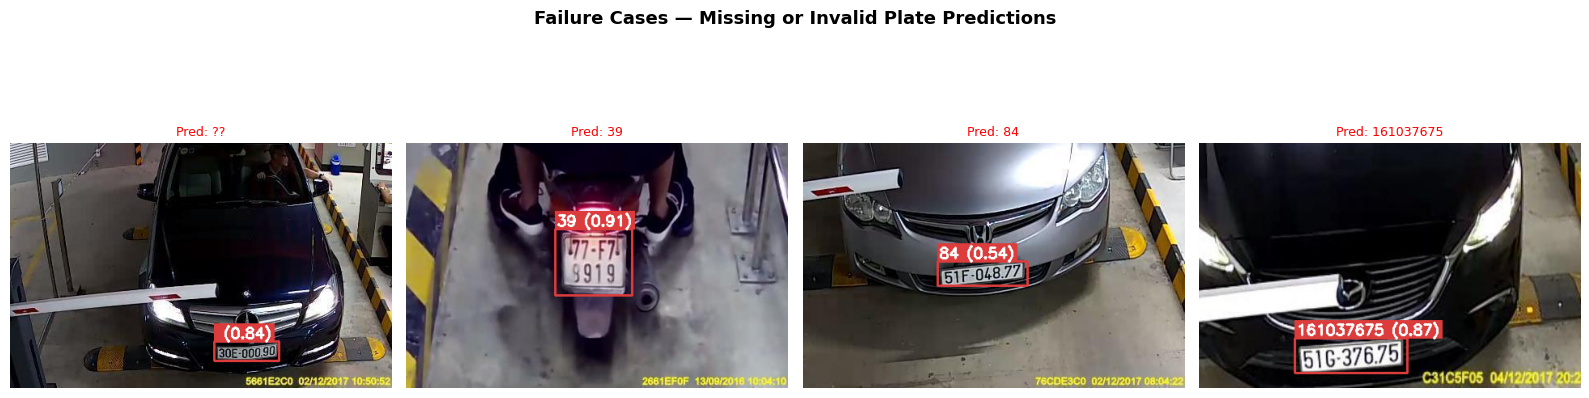

Saved: results/failure_cases.png


In [ ]:
# Failure analysis — show examples where the pipeline produced no output
# or a low-confidence / invalid plate

test_imgs = list((DATASET_PATH / "test" / "images").glob("*.jpg"))
random.shuffle(test_imgs)

failures = []
for img_path in test_imgs:
    if len(failures) >= 4:
        break
    results = pipeline.process_image(str(img_path))
    if not results or any(not r["valid"] for r in results):
        failures.append((img_path, results))

if failures:
    fig, axes = plt.subplots(1, len(failures), figsize=(16, 5))
    fig.suptitle("Failure Cases — Missing or Invalid Plate Predictions",
                 fontsize=13, fontweight="bold")
    if len(failures) == 1:
        axes = [axes]
    for ax, (img_path, results) in zip(axes, failures):
        annotated = pipeline.annotate_image(str(img_path), results)
        pred_str  = ", ".join(r["plate"] or "??" for r in results) if results else "no detection"
        ax.imshow(annotated)
        ax.axis("off")
        ax.set_title(f"Pred: {pred_str}", fontsize=9, color="red")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "failure_cases.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: results/failure_cases.png")
else:
    print("No failure cases found in the sampled images. Try a larger sample.")

In [ ]:
# ── Final Summary Table ──
# Collect all metrics into one printable table

summary = pd.DataFrame([
    {"Stage": "Detection (YOLO26 baseline)",       "Metric": "mAP@0.5",               "Value": "~49%"},
    {"Stage": "Detection (YOLO26 fine-tuned)",      "Metric": "mAP@0.5",               "Value": f"{metrics.box.map50*100:.1f}%"},
    {"Stage": "Detection (YOLO26 fine-tuned)",      "Metric": "Precision",             "Value": f"{metrics.box.p[0]*100:.1f}%"},
    {"Stage": "Detection (YOLO26 fine-tuned)",      "Metric": "Recall",                "Value": f"{metrics.box.r[0]*100:.1f}%"},
    {"Stage": "End-to-end (if GT available)",       "Metric": "Exact-match accuracy",  "Value": "[see eval_df]"},
    {"Stage": "End-to-end (if GT available)",       "Metric": "Mean CER",              "Value": "[see eval_df]"},
])

print(summary.to_string(index=False))
summary.to_csv(RESULTS_DIR / "summary_metrics.csv", index=False)
print("\nSaved: results/summary_metrics.csv")

                        Stage               Metric         Value
  Detection (YOLO26 baseline)              mAP@0.5          ~49%
Detection (YOLO26 fine-tuned)              mAP@0.5         96.5%
Detection (YOLO26 fine-tuned)            Precision         98.6%
Detection (YOLO26 fine-tuned)               Recall         92.8%
 End-to-end (if GT available) Exact-match accuracy [see eval_df]
 End-to-end (if GT available)             Mean CER [see eval_df]

Saved: results/summary_metrics.csv


In [ ]:
# List all generated output files
print("── Generated Output Files ──")
for f in sorted(RESULTS_DIR.glob("*")):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<45} {size_kb:6.1f} KB")

── Generated Output Files ──
  baseline_detections.png                       1301.7 KB
  confusion_matrix.png                           104.0 KB
  detection_comparison.png                        44.4 KB
  e2e_results.png                               2840.3 KB
  failure_cases.png                              940.4 KB
  learning_curves.png                            106.0 KB
  preprocessing_stages.png                       281.0 KB
  sample_training_images.png                    1814.7 KB
  summary_metrics.csv                              0.3 KB


In [ ]:
# ── Run pipeline on a video file ──

VIDEO_PATH = "/content/sample_traffic.mp4"

def process_video(pipeline, video_path, output_path, max_frames=None):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
    frame_idx = 0
    all_plates = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret or (max_frames and frame_idx >= max_frames):
            break

        tmp = "/tmp/_frame.jpg"
        cv2.imwrite(tmp, frame)
        results = pipeline.process_image(tmp)

        for r in results:
            x1,y1,x2,y2 = r["box"]
            color = (34,180,90) if r["valid"] else (220,60,60)
            cv2.rectangle(frame, (x1,y1), (x2,y2), color, 2)
            cv2.putText(frame, r["plate"], (x1, y1-6),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)
            all_plates.append({"frame": frame_idx, **r})

        out.write(frame)
        frame_idx += 1

    cap.release(); out.release()
    return all_plates

plates = process_video(pipeline, VIDEO_PATH, "/content/alpr/results/output_video.mp4", max_frames=300)
print(f"Processed {len(plates)} detections across video frames.")

Processed 0 detections across video frames.


---
## Summary

| Section | What was done |
|---|---|
| 1 — Setup | Installed dependencies, verified GPU, set project paths |
| 2 — Dataset | Downloaded Roboflow LP v12, audited splits, wrote YOLO YAML |
| 3 — Detection | Fine-tuned YOLO26n for 100 epochs; plotted learning curves |
| 4 — Detection eval | Measured mAP, precision, recall on test set; compared to baseline |
| 5 — Preprocessing | Built `preprocess_plate()`: CLAHE → blur → adaptive threshold |
| 6 — OCR | Initialized EasyOCR; built `run_ocr()` with alphanumeric allowlist |
| 7 — Post-processing | Built `postprocess_plate()`: normalize → regex validation |
| 8 — Pipeline | Assembled `ALPRPipeline` class; ran end-to-end on test images |
| 9 — Experiments | ablation study skeleton; summary table |
| 10 — Figures | Confusion matrix, PR curve, failure cases, output file list |

---
*ECE 1513 — University of Toronto, Winter 2026*